### Question:
**How does German electricity consumption vary across time, and what does the long-term decline look like when broken down by hour, day, and season?**

## Section 1 - Setup

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from notebooks.eda.eda_utils import smard_wide_local, load_weather
from datetime import date

In [3]:
df = smard_wide_local()
print(df.shape)
df.head()

2026-06-17 14:41:54,181 - INFO - Loading SMARD data (2019-01-01 → 2025-12-31)
2026-06-17 14:41:57,973 - INFO - Loaded 1394735 SMARD rows across 23 signals
2026-06-17 14:41:58,001 - INFO - Pivoting 1394735 rows x 23 signals to wide format


(61368, 29)


,timestamp,AUSTRIA,BIOMASS,BROWN_COAL,CZECHIA,DENMARK_1,DENMARK_2,DE_LU,FRANCE,HARD_COAL,...,SOLAR,SWITZERLAND,TOTAL_CONSUMPTION,WIND_OFFSHORE,WIND_ONSHORE,hour_local,date_local,dow,month_local,season
0,2019-01-01 00:00:00+00:00,39.76,4737.25,5379.50,3.97,10.07,10.07,10.07,46.27,2404.25,...,0.0,48.74,41631.25,2868.25,22297.25,1,2019-01-01,1,1,winter
1,2019-01-01 01:00:00+00:00,39.78,4694.00,5341.00,4.70,-4.08,-4.08,-4.08,39.78,2228.50,...,0.0,47.24,40085.00,2460.25,23168.50,2,2019-01-01,1,1,winter
2,2019-01-01 02:00:00+00:00,27.87,4669.75,5270.75,0.93,-9.91,-9.91,-9.91,27.87,2356.75,...,0.0,36.29,39269.75,2696.50,24471.75,3,2019-01-01,1,1,winter
3,2019-01-01 03:00:00+00:00,-0.36,4681.75,5178.75,3.90,-7.41,-7.41,-7.41,23.21,2308.50,...,0.0,30.09,39032.75,2578.00,26320.50,4,2019-01-01,1,1,winter
4,2019-01-01 04:00:00+00:00,-4.45,4678.00,5076.50,7.95,-12.55,-12.55,-12.55,22.64,2311.25,...,0.0,27.31,38570.50,2377.25,27898.00,5,2019-01-01,1,1,winter


In [4]:
weather = load_weather()
print(weather.shape)
weather.head()

2026-06-17 14:42:12,240 - INFO - Loading weather data (2019-01-01 → 2025-12-31)
2026-06-17 14:42:16,017 - INFO - Loaded 1227360 weather rows


(1227360, 5)


,timestamp,region,signal_type,value,unit
0,2019-01-01 00:00:00+00:00,wind_region_brandenburg,wind_speed_100m,31.8,km/h
1,2019-01-01 01:00:00+00:00,wind_region_brandenburg,wind_speed_100m,33.1,km/h
2,2019-01-01 02:00:00+00:00,wind_region_brandenburg,wind_speed_100m,33.1,km/h
3,2019-01-01 03:00:00+00:00,wind_region_brandenburg,wind_speed_100m,43.9,km/h
4,2019-01-01 04:00:00+00:00,wind_region_brandenburg,wind_speed_100m,42.9,km/h


In [7]:
from ingestion.weather_client import SignalType

# Aggregate weather to national hourly temperature
temp_national = (
    weather[weather["signal_type"] == SignalType.TEMPERATURE.value]
    .groupby("timestamp")["value"]
    .mean()
    .rename("temperature_c")
)

# Combine for downstream sections that need both
combined = df.set_index("timestamp").join(temp_national, how="inner")
combined = combined.reset_index()

In [8]:
from ingestion.smard_client import ENERGY_SOURCE

COLORS = {
    ENERGY_SOURCE.WIND_ONSHORE.name: "#9ecae1",       # light blue
    ENERGY_SOURCE.WIND_OFFSHORE.name: "#3182bd",      # darker blue
    ENERGY_SOURCE.SOLAR.name: "#fdd835",              # yellow
    ENERGY_SOURCE.BIOMASS.name: "#74c476",            # green
    ENERGY_SOURCE.HYDROPOWER.name: "#41b6c4",         # cyan
    ENERGY_SOURCE.OTHER_RENEWABLE.name: "#a1d99b",    # light green
    ENERGY_SOURCE.NUCLEAR.name: "#e377c2",            # pink (often pink/magenta in industry)
    ENERGY_SOURCE.BROWN_COAL.name: "#8c564b",         # brown
    ENERGY_SOURCE.HARD_COAL.name: "#525252",          # dark gray
    ENERGY_SOURCE.NATURAL_GAS.name: "#ff7f0e",        # orange
    ENERGY_SOURCE.OTHER_CONVENTIONAL.name: "#bdbdbd", # light gray
    ENERGY_SOURCE.PUMPED_STORAGE.name: "#9467bd",     # purple (storage)
}

COLORS

{'WIND_ONSHORE': '#9ecae1',
 'WIND_OFFSHORE': '#3182bd',
 'SOLAR': '#fdd835',
 'BIOMASS': '#74c476',
 'HYDROPOWER': '#41b6c4',
 'OTHER_RENEWABLE': '#a1d99b',
 'NUCLEAR': '#e377c2',
 'BROWN_COAL': '#8c564b',
 'HARD_COAL': '#525252',
 'NATURAL_GAS': '#ff7f0e',
 'OTHER_CONVENTIONAL': '#bdbdbd',
 'PUMPED_STORAGE': '#9467bd'}

In [9]:
from notebooks.eda.eda_utils import ENERGY_GROUP, get_all_sources, get_sources_by_energy_group

GENERATION_SOURCES = get_all_sources()

GENERATION_SOURCES_NO_STORAGE = get_all_sources()
GENERATION_SOURCES_NO_STORAGE.remove(ENERGY_SOURCE.PUMPED_STORAGE.name)

RENEWABLE_SOURCES = get_sources_by_energy_group(ENERGY_GROUP.RENEWABLE)
FOSSIL_SOURCES = get_sources_by_energy_group(ENERGY_GROUP.FOSSIL)
NUCLEAR_SOURCES = get_sources_by_energy_group(ENERGY_GROUP.NUCLEAR)
COAL_SOURCES = [ENERGY_SOURCE.BROWN_COAL.name, ENERGY_SOURCE.HARD_COAL.name]

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

## Section 2 — Annual trend and seasonal cycle

### Annual Decline

timestamp
2019    56777.146832
2020    55254.770719
2021    57602.840696
2022    55055.979366
2023    52326.890011
2024    52995.267450
2025    53175.349807
Name: TOTAL_CONSUMPTION, dtype: float64


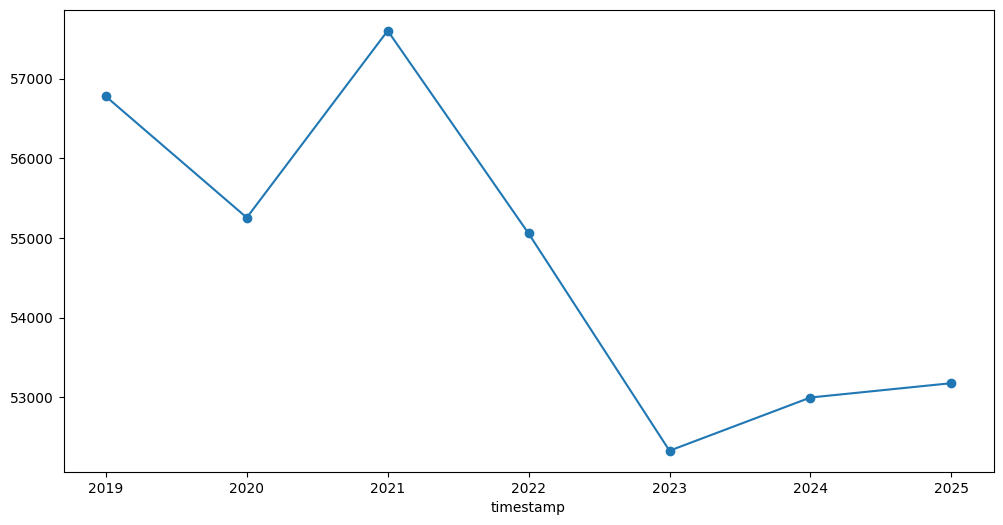

In [15]:
from ingestion.smard_client import CONSUMPTION_TYPE

annual = df.groupby(df["timestamp"].dt.year)[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name].mean()
annual.plot(figsize=(12, 6), marker="o")
print(annual)

* Consumption stepped down twice. Pre-crisis baseline 2019–2021 averaged ~56-58 GW. The 2022 gas crisis destroyed ~2.5 GW of demand within a year. The 2023 nuclear phase-out and continued high prices took another ~2.8 GW. Since 2024, consumption has stabilized at a new lower baseline ~3.5–4 GW below pre-crisis levels.

### Monthly seasonal cycle

month_local
1     60311.533867
2     60337.014621
3     57093.541294
4     53060.240355
5     51154.622419
6     51163.642992
7     51579.849687
8     50594.845593
9     52353.970135
10    54582.690019
11    58202.413935
12    56812.441081
Name: TOTAL_CONSUMPTION, dtype: float64


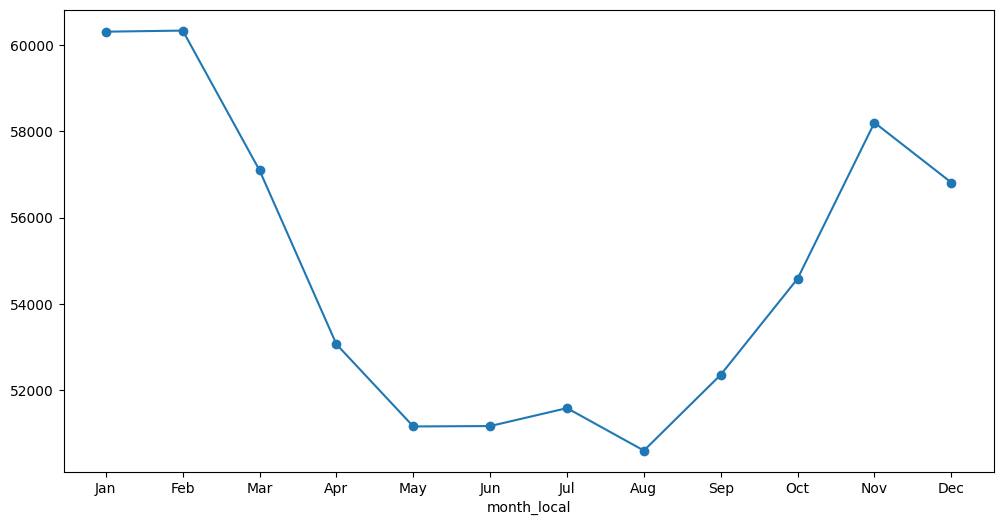

In [18]:
monthly = df.groupby("month_local")["TOTAL_CONSUMPTION"].mean()

ax = monthly.plot(figsize=(12, 6), marker="o")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])

print(monthly)

* Winter peak (Jan/Feb ~60.3 GW) is ~10 GW above summer trough (Aug ~50.5 GW). 
* December is notably lower than November (56.8 vs 58.2 GW) due to holiday-period industrial slowdown
* The highest-stress periods for the grid are early January and February, not Christmas week.

## Section 3 — Weekly cycle 

dow
0    56430.683511
1    58107.114891
2    58210.633243
3    57882.443448
4    56771.169038
5    49397.548338
6    46366.574745
Name: TOTAL_CONSUMPTION, dtype: float64


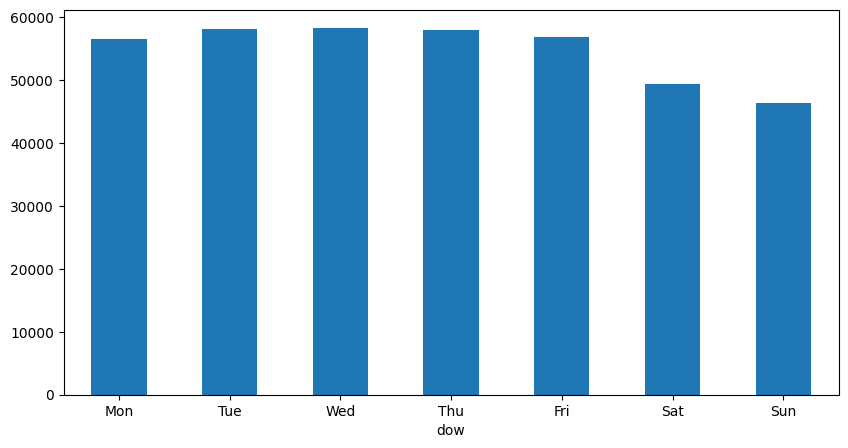

In [21]:
weekly = df.groupby("dow")[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name].mean()

ax=weekly.plot.bar(figsize=(10, 5))
ax.set_xticklabels(DOW_LABELS, rotation=0)

print(weekly)

* The weekly industrial signal is ~11.1 GW. German consumption averages 57.5 GW on weekdays (Mon-Fri) and drops to 46.4 GW on Sundays — a swing equivalent to all of Germany's pre-phase-out nuclear output. Saturday sits between (49.5 GW), indicating substantial industrial activity continues on Saturdays. The midweek peak (Wed, 58.3 GW) shows a clear ramp from Monday's "warm-up" (56.5 GW) and a Friday "wind-down" (56.9 GW), suggesting structured operational cycles in German manufacturing.

In [22]:
weekday_avg = df[df["dow"].between(0, 4)]["TOTAL_CONSUMPTION"].mean()
sunday_avg  = df[df["dow"] == 6]["TOTAL_CONSUMPTION"].mean()
print(f"Weekday average: {weekday_avg:.0f} MW")
print(f"Sunday average:  {sunday_avg:.0f} MW")
print(f"Industrial signal: {weekday_avg - sunday_avg:.0f} MW")

Weekday average: 57481 MW
Sunday average:  46367 MW
Industrial signal: 11115 MW


In [32]:
def industrial_signal(group):
    weekday = group[group["dow"].between(0, 4)]["TOTAL_CONSUMPTION"].mean()
    sunday = group[group["dow"] == 6]["TOTAL_CONSUMPTION"].mean()
    return weekday - sunday

gap_by_year = df.groupby(df["timestamp"].dt.year).apply(industrial_signal)
print(gap_by_year.round(0))

timestamp
2019    12377.0
2020    11147.0
2021    11530.0
2022    11131.0
2023    10915.0
2024    10348.0
2025    10310.0
dtype: float64


* Industrial demand destruction accounts for ~60% of Germany's post-crisis consumption decline. 
* The weekday-Sunday gap (the "industrial signal") has shrunk from 12.4 GW in 2019 to 10.3 GW in 2025. 
* Decomposed: weekday consumption fell ~4.2 GW from 60.3 to 56.1 GW; Sunday consumption fell only ~2.1 GW from 47.9 to 45.8 GW. 
* Weekday demand fell twice as fast as Sunday demand, indicating that the decline is concentrated in industrial activity rather than residential consumption. 
* The 2020 COVID year provides a useful comparison: 
    * it shows what a temporary industrial slowdown looks like (-1.3 GW gap, fully recovered by 2021), in contrast to the post-2022 decline which has not recovered.

## Section 4 — Diurnal pattern

hour_local
0     46232.865119
1     44548.477188
2     43683.430563
3     43739.921177
4     44627.003438
5     46931.831639
6     51934.777595
7     56222.791330
8     59152.535244
9     60533.008698
10    61553.373336
11    62402.498553
12    61931.357536
13    60688.872296
14    59354.727067
15    58645.418936
16    58446.701185
17    59641.154009
18    60314.813664
19    59717.690465
20    57374.131212
21    54835.519437
22    52324.793676
23    48939.008275
Name: TOTAL_CONSUMPTION, dtype: float64


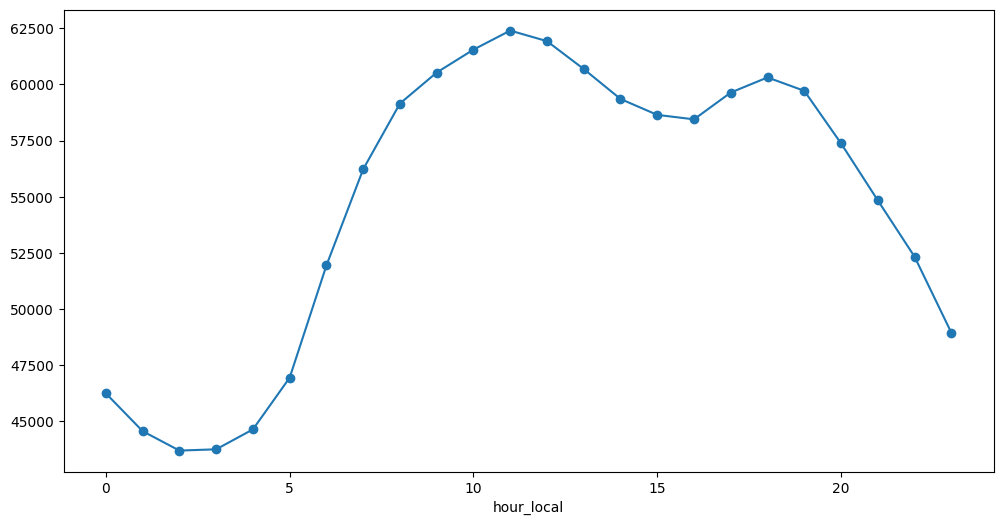

In [23]:
diurnal = df.groupby("hour_local")["TOTAL_CONSUMPTION"].mean()

diurnal.plot(figsize=(12, 6), marker="o")
print(diurnal)

The diurnal pattern has a "morning supply gap" of 6–7 hours. Consumption ramps from 43.7 GW (hour 3) to 62.4 GW (hour 11) — a 19 GW increase — but solar generation only becomes significant after hour 9. The most demand-stressed hours (08:00–11:00) coincide with the renewable troughs from notebook 02 (wind at its daily minimum, solar still ramping). This is the period when Germany most relies on conventional generation and imports.

**NOTE** 
- Compare this to the renewable diurnal patterns from notebook 02: solar peaks at 12–13h, which is between the two consumption peaks. The morning consumption ramp at 5–9am happens before solar produces meaningfully — that's the "morning gap" that traditionally needed gas peakers and now needs imports.

## Section 5 — The consumption fingerprint

In [24]:
fingerprint = (
    df.groupby(["dow", "hour_local"])[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name]
    .mean()
    .unstack("hour_local")
)

fingerprint.index = DOW_LABELS

Text(0.5, 1.0, 'German electricity consumption: day of week x hour of day')

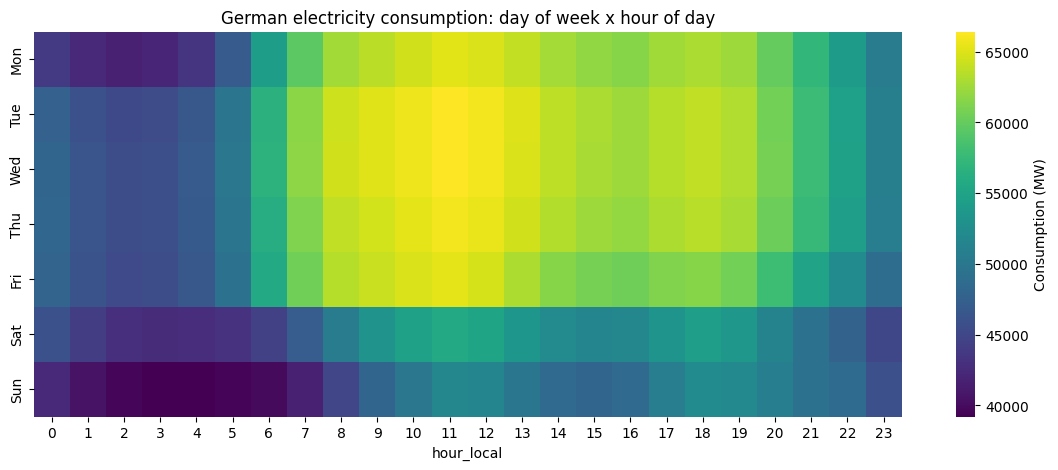

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(fingerprint, cmap="viridis", ax=ax,
            cbar_kws={"label": "Consumption (MW)"})
ax.set_title("German electricity consumption: day of week x hour of day")

* The weekday rows (Mon-Fri) look nearly identical to each other 
* A horizontal band of higher color from 6am to 20h. 
* Saturday slightly cooler in the daytime band. 
* Sunday distinctly different — much lower daytime values, with the morning ramp delayed by an hour or two. 
* This is Germany's "operating rhythm" in one image.

* German weekday consumption is remarkably uniform Tue–Thu with the morning ramp, peak, and evening decline almost identical across these three days. Monday shows a slower start (cold early hours, delayed ramp) and Friday shows an earlier evening wind-down. Saturday remains operationally meaningful (between weekdays and Sunday), reflecting partial Saturday-shift activity in German manufacturing.

## Section 6 — Temperature dependence

In [27]:
# Bin temperature into 2-degree buckets
combined["temp_bin"] = pd.cut(combined["temperature_c"], bins=range(-15, 36, 2))

temp_response = (
    combined.groupby("temp_bin", observed=True)[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name]
    .agg(["mean", "count"])
)

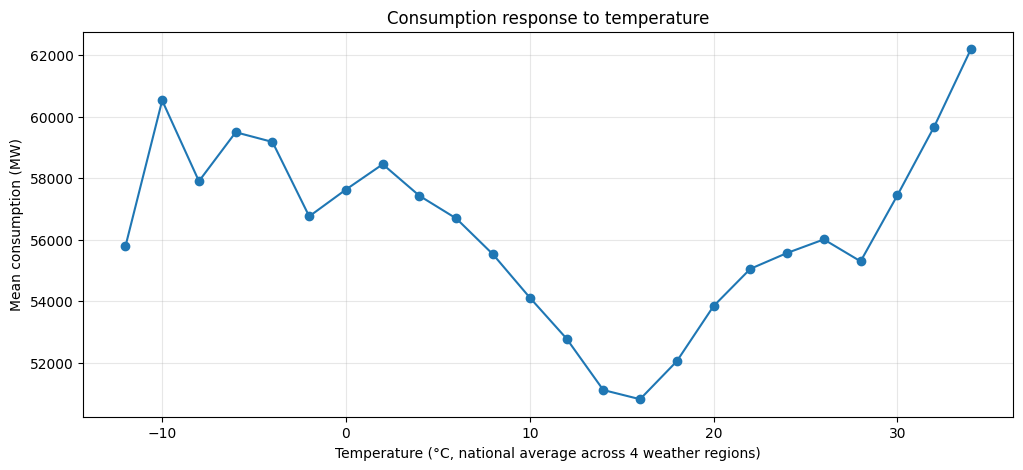

In [28]:
# Plot with point sizes proportional to sample size
fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(
    x=[interval.mid for interval in temp_response.index],
    y=temp_response["mean"],
    fmt="o-",
)
ax.set_xlabel("Temperature (°C, national average across 4 weather regions)")
ax.set_ylabel("Mean consumption (MW)")
ax.set_title("Consumption response to temperature")
ax.grid(True, alpha=0.3)

In [30]:
# Rough heating elasticity (below 15°C)
heating_data = combined[combined["temperature_c"] < 15]
slope = (heating_data[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name].corr(heating_data["temperature_c"]) *
         heating_data[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name].std() / heating_data["temperature_c"].std())
print(f"Heating elasticity: {slope:.0f} MW per °C")

Heating elasticity: -461 MW per °C


In [34]:
cooling_data = combined[combined["temperature_c"] > 18]
slope_cool = (cooling_data["TOTAL_CONSUMPTION"].corr(cooling_data["temperature_c"]) *
              cooling_data["TOTAL_CONSUMPTION"].std() / cooling_data["temperature_c"].std())
print(f"Cooling elasticity: +{slope_cool:.0f} MW per °C")

Cooling elasticity: +453 MW per °C


* German consumption has a near-symmetric V-shaped response to temperature. 
* Heating elasticity below 15 °C is −461 MW/°C; cooling elasticity above 18 °C is +453 MW/°C. 
* The cooling sensitivity is essentially identical to heating sensitivity despite Germany's historically low AC penetration, reflecting recent growth in residential AC adoption, data centre cooling, and industrial process cooling — all expanded markedly after the 2018, 2022, and 2023 heat waves. 
* Total heating impact remains larger than cooling because Germany's temperature range extends further below the comfort zone than above it.

## Section 7 — Residula Load & Decline decomposition

In [36]:
# Annual mean — should be declining as renewables grow
annual_mean = df.groupby(df["timestamp"].dt.year)[CONSUMPTION_TYPE.RESIDUAL_LOAD.name].mean()

# Annual std — should be INCREASING as renewable variability propagates
annual_std = df.groupby(df["timestamp"].dt.year)[CONSUMPTION_TYPE.RESIDUAL_LOAD.name].std()

# Together
print(pd.DataFrame({"mean": annual_mean, "std": annual_std}).round(0))

              mean      std
timestamp                  
2019       37850.0  12317.0
2020       35247.0  12370.0
2021       39357.0  12257.0
2022       34341.0  12478.0
2023       29716.0  13538.0
2024       30070.0  13525.0
2025       29574.0  15041.0


Residual load has become significantly more variable even as it has shrunk. Mean residual load fell from 37.8 GW (2019) to 29.6 GW (2025) as renewables displaced conventional generation. Over the same window, the standard deviation rose from 12.3 GW to 15.0 GW, and the coefficient of variation went from 32.5% to 50.9% — a 56% increase in relative volatility. This is the structural mechanism behind growing European price volatility: renewable variability propagates directly into residual load and prices.

Text(0.5, 1.0, 'Hourly consumption change: 2025 vs 2019 (MW)')

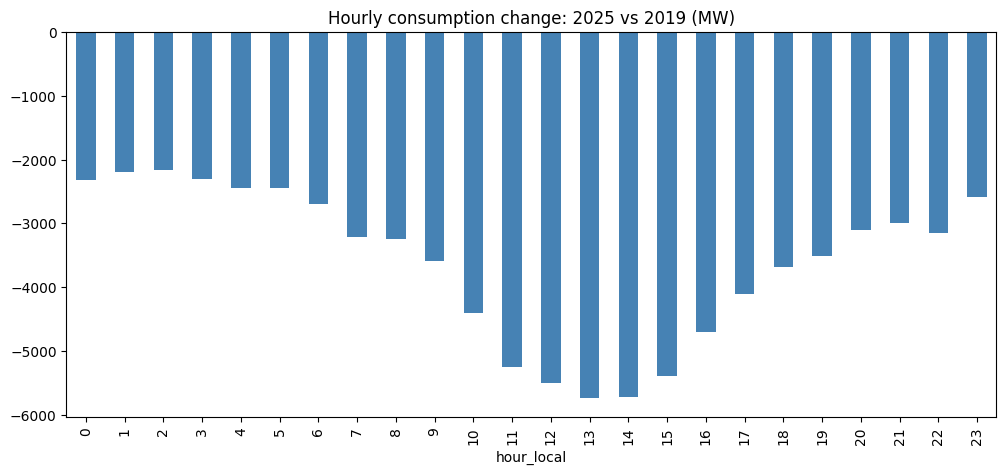

In [31]:
delta = (
    df[df["timestamp"].dt.year == 2025].groupby("hour_local")[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name].mean()
  - df[df["timestamp"].dt.year == 2019].groupby("hour_local")[CONSUMPTION_TYPE.TOTAL_CONSUMPTION.name].mean()
)
delta.plot(kind="bar", figsize=(12, 5), color="steelblue")
plt.axhline(0, color="black", linewidth=0.5)
plt.title("Hourly consumption change: 2025 vs 2019 (MW)")

* Germany's consumption decline is concentrated in industrial peak hours. 
* Hour 14 (local time) has fallen 5,700 MW from 2019 to 2025 — 2.6× the decline at overnight hours (~2,200 MW). 
* The decline pattern follows the industrial activity profile rather than uniform demand reduction, confirming from a third angle that the structural decline is primarily industrial rather than residential or efficiency-driven.

## Section 8 — Findings

Seven-year analysis (2019-01-01 to 2025-12-31) of German electricity
consumption patterns, combining SMARD TOTAL_CONSUMPTION and RESIDUAL_LOAD
signals with national-average temperature derived from 4 regional
Open-Meteo series.

### Headline findings

1. **Consumption declined in two distinct shocks, not gradually.**
   The 2019-2021 baseline averaged 56-58 GW (2021 peak: 57.6 GW). The
   2022 gas crisis destroyed ~2.5 GW of demand. The 2023 nuclear
   phase-out and continued high prices took another ~2.8 GW. Since
   2024, consumption has stabilized at ~53 GW — about 3.5-4 GW below
   the pre-crisis baseline. Peak-to-trough (2021 → 2023) was 5.3 GW.

2. **The decline is concentrated in industrial activity, not residential.**
   Three independent decompositions confirm this:
   - Weekly: the weekday-Sunday gap shrunk from 12.4 GW (2019) to
     10.3 GW (2025), a 2.1 GW reduction in the "industrial signal."
   - Algebraically: weekday consumption fell 4.2 GW (60.3 → 56.1 GW);
     Sunday consumption fell only 2.1 GW (47.9 → 45.8 GW).
   - Hourly: the decline at hour 14 is 5,700 MW vs only 2,200 MW
     at hour 2 — a 2.6× difference matching the industrial activity
     profile.

3. **Winter peak vs summer trough is ~10 GW.** Jan/Feb average 60.3 GW;
   Aug averages 50.5 GW. December is *lower* than November (56.8 vs
   58.2 GW) due to Christmas/New Year industrial slowdown — the
   highest-stress periods for the grid are early January and February,
   not Christmas week.

4. **The weekly industrial signal is ~11.1 GW** (Wed peak 58.3 GW vs
   Sun trough 46.4 GW). Saturday (49.5 GW) sits between weekdays and
   Sunday, indicating substantial Saturday-shift activity in German
   manufacturing. Mon-Fri shows a clear sub-structure: Monday "warm-up"
   (~1.8 GW below Wed), Tue/Wed/Thu uniform peak operations, Friday
   "wind-down" (~1.4 GW below Wed).

5. **The diurnal peak is in the morning, not the evening.** Hour 11
   averages 62.4 GW, hour 18 only 60.3 GW. This morning-peak signature
   is characteristic of industrial-heavy load profiles, opposite to
   residential-heavy grids where the evening peak dominates. Daily
   peak-to-trough range is 18.7 GW (62.4 at 11h vs 43.7 at 3h); morning
   ramp from 05:00 to 11:00 averages 2.6 GW/hour for six consecutive
   hours.

6. **A structural "morning supply gap" exists between 05:00 and 12:00.**
   Consumption is already at 91% of its daily peak by 09:00, but solar
   production averages less than 4 GW at that hour even in summer, and
   wind is at its daily minimum (from notebook 02). This 6-hour window
   is when Germany most depends on conventional generation and imports.

7. **Consumption response to temperature is near-symmetric and V-shaped.**
   Heating elasticity below 15°C is -461 MW/°C; cooling elasticity above
   18°C is +453 MW/°C. The cooling sensitivity is essentially identical
   to heating despite Germany's historically low AC penetration —
   reflecting recent growth in residential AC adoption, data centre
   cooling, and industrial process cooling following multiple heat
   waves (2018, 2022, 2023). Total heating impact remains larger only
   because Germany's temperature range extends further below the
   comfort zone than above it.

8. **Residual load variability has grown 56% even as its mean has
   shrunk 22%.** Mean residual load fell from 37.8 GW (2019) to
   29.6 GW (2025) as renewables displaced conventional generation. Over
   the same window, standard deviation rose from 12.3 GW to 15.0 GW,
   and the coefficient of variation went from 32.5% to 50.9% — a 56%
   increase in relative volatility. This is the structural mechanism
   behind growing European price volatility: renewable variability
   propagates directly into residual load and prices.

### Implications for downstream phases

- **Phase 4 (ML):** The price model's training window restriction
  to post-2023-04-16 (established in notebook 01) is reinforced —
  residual load variability stepped up around the same time.
  Hour-of-day, day-of-week, and temperature should all be features.
  The temperature relationship contains hour/season confounding that
  interaction terms can disentangle.

- **Phase 6 (dashboard):** Three dashboard-ready charts:
  - Day-of-week × hour-of-day consumption heatmap (Historical Overview)
  - Annual mean and std of residual load (Market Monitor — the
    volatility story is the single most important operational metric)
  - Temperature V-curve (Historical Overview, optional)
  
  Recommended framing for current-conditions displays: "current value
  vs typical for this hour, day, and temperature" rather than
  "current value vs daily average."

- **Cross-cutting:** Notebook 03 connects directly to notebook 01's
  net-import finding. The morning supply gap (05:00-12:00) is when
  imports are most needed; the growing residual load volatility means
  the import need itself is highly variable. This makes neighbour-price
  spread analysis (notebook 05) the most important downstream work.